In [139]:
import pandas as pd
import numpy as nb
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Task 1: Data Ingestion & Quality Profiling

##### 1.1 Load & Inspect

In [140]:
# Read car_prices.csv into a pandas DataFrame

df = pd.read_csv('car_prices.csv')

In [141]:
# Display the first 5 rows.

df.head(5)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [142]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [143]:
# Display data record count.
print('Data record count are',len(df))

# Display data types.
df.dtypes

Data record count are 558837


year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object

##### 1.2. Understanding the Data Structure

In [144]:
# Check the shape of the dataset.
print('Shape of the dataset is:', df.shape)

Shape of the dataset is: (558837, 16)


In [145]:
# Check the shape of the dataset (columns).
print('Shape of the dataset (column) is:',df.columns)

Shape of the dataset (column) is: Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='str')


In [146]:
# Display column names and data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


##### 1.3. Missing & Anomaly Detection

In [147]:
# Quantify nulls per column.
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [148]:
# percentage of null value
(df.isnull().sum() / len(df) * 100).round(1)

year             0.0
make             1.8
model            1.9
trim             1.9
body             2.4
transmission    11.7
vin              0.0
state            0.0
condition        2.1
odometer         0.0
color            0.1
interior         0.1
seller           0.0
mmr              0.0
sellingprice     0.0
saledate         0.0
dtype: float64

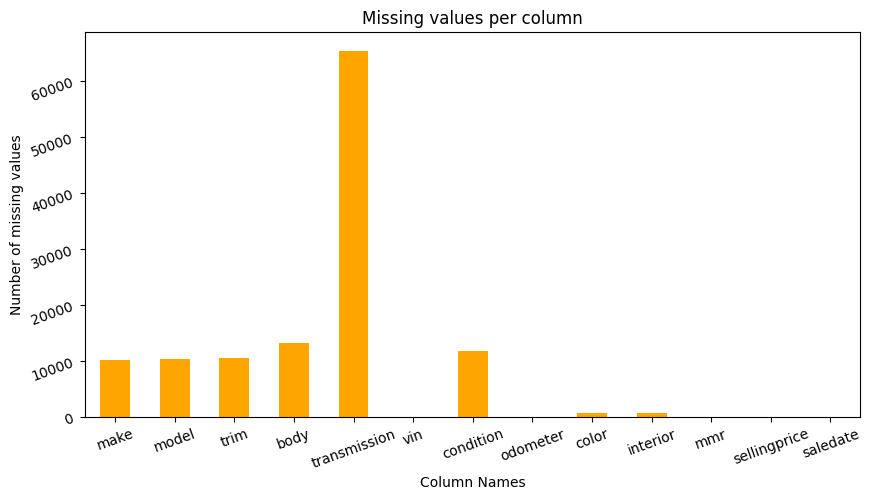

In [149]:
# Visualize with a bar chart.
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]

plt.figure(figsize=(10,5))
null_counts.plot(kind='bar',color='orange')
plt.xlabel('Column Names')
plt.ylabel('Number of missing values')
plt.title('Missing values per column')
plt.xticks(rotation=20)
plt.yticks(rotation=20)

plt.show()

In [150]:
# Resolve null values by appropriate strategy based on the datatype and percentage of null values.

# Resolve Categorical columns with 'Unknown'
cat_cols = ['make', 'model', 'trim', 'body', 'transmission', 'color', 'interior']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')


# Resolve Numeric columns with median
num_cols = ['condition', 'odometer', 'mmr']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


# Drop rows where important columns are still missing
df = df.dropna(subset=['sellingprice', 'vin', 'saledate', 'state'])


df.isnull().sum()

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
mmr             0
sellingprice    0
saledate        0
dtype: int64

In [151]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print('Shape after removing duplicate:', df.shape)

Duplicate rows: 0
Shape after removing duplicate: (558821, 16)


### Task 2: Remove duplicates

##### 2.1 Calculate the average, minimum, and maximum car price

In [152]:
print('Average price:', df['sellingprice'].mean())
print('Minimum price:', df['sellingprice'].min())
print('Maximum price:', df['sellingprice'].max())

Average price: 13611.358175515952
Minimum price: 1.0
Maximum price: 230000.0


##### 2.2 List all unique colors of cars

In [153]:
colors = df['color'].unique()
print('Number of unique colors:',len(colors))
print(colors)

Number of unique colors: 43
<StringArray>
[    'white',      'gray',     'black',       'red',    'silver',      'blue',
     'brown',     'beige',    'purple',  'burgundy',         '—',      'gold',
    'yellow',     'green',  'charcoal',   'Unknown',    'orange', 'off-white',
 'turquoise',      'pink',      'lime',      '4802',      '9410',      '1167',
      '2172',     '14872',     '12655',     '15719',      '6388',     '16633',
     '11034',      '6864',       '339',     '18384',      '9887',      '9837',
     '20627',       '721',      '6158',      '5705',     '18561',      '2846',
      '5001']
Length: 43, dtype: str


##### 2.3 Find the number of unique car brands and car models

In [154]:
print('Number of unique brands:',df['make'].nunique())
print('Number of unique models:',df['model'].nunique())

Number of unique brands: 97
Number of unique models: 974


##### 2.4 Find all car information having selling prices greater than $165000

In [155]:
expensive_cars = df[df['sellingprice'] > 165000]
print('Number of cars:', len(expensive_cars))
expensive_cars

Number of cars: 7


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
125095,2012,Rolls-Royce,Ghost,Base,Sedan,automatic,sca664s58cux50727,fl,45.0,14316.0,black,beige,braman motorcars,154000.0,169500.0,Wed Jan 14 2015 01:40:00 GMT-0800 (PST)
344905,2014,Ford,Escape,Titanium,SUV,automatic,1fmcu9j98eua23833,mo,43.0,27802.0,green,tan,ford-lincoln dealer program,22800.0,230000.0,Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
446949,2015,Mercedes-Benz,S-Class,S65 AMG,Sedan,automatic,wddug7kb2fa102347,ca,41.0,5277.0,white,white,mercedes-benz usa,170000.0,173000.0,Thu May 21 2015 05:00:00 GMT-0700 (PDT)
538347,2012,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s59cux50803,ca,44.0,5215.0,white,tan,financial services remarketing (bmw int),166000.0,167000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)
545523,2013,Rolls-Royce,Ghost,Base,sedan,automatic,sca664s52dux52152,fl,42.0,7852.0,white,beige,flag/landrover southpointe,178000.0,171500.0,Wed Jun 17 2015 03:05:00 GMT-0700 (PDT)
548169,2011,Ferrari,458 Italia,Base,coupe,automatic,zff67nfa1b0178698,fl,46.0,12116.0,red,black,platinum motor cars,182000.0,183000.0,Wed Jun 17 2015 03:40:00 GMT-0700 (PDT)
557570,2012,Rolls-Royce,Ghost,EWB,sedan,automatic,sca664l50cux65625,ca,36.0,11832.0,white,black,bentley scottsdale,164000.0,169000.0,Thu Jun 18 2015 05:30:00 GMT-0700 (PDT)


##### 2.5 Find the top 5 most frequently sold car models

In [156]:
df['model'].value_counts().head(5)

model
Altima    19349
F-150     14479
Fusion    12945
Camry     12545
Escape    11861
Name: count, dtype: int64

##### 2.6 What is the average selling price of cars by brand (make)

In [157]:
df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)

make
Rolls-Royce    153488.235294
Ferrari        127210.526316
Lamborghini    112625.000000
Bentley         74367.672414
airstream       71000.000000
                   ...      
dodge tk          550.000000
Geo               528.947368
dot               500.000000
ford truck        483.333333
Daewoo            400.000000
Name: sellingprice, Length: 97, dtype: float64

##### 2.7 What is the minimum selling price of cars for each interior

In [158]:
df.groupby('interior')['sellingprice'].min().sort_values()

interior
black           1.0
gray            1.0
beige         100.0
green         100.0
tan           100.0
silver        150.0
blue          150.0
—             150.0
burgundy      175.0
red           200.0
brown         200.0
purple        200.0
Unknown       225.0
gold          250.0
white         350.0
off-white     900.0
orange       1200.0
yellow       3100.0
Name: sellingprice, dtype: float64

##### 2.8 Find highest odometer reading per year from highest to lowest order

In [159]:
df.groupby('year')['odometer'].max().sort_values(ascending=False)

year
1997    999999.0
1996    999999.0
2014    999999.0
2013    999999.0
1998    999999.0
1999    999999.0
1993    999999.0
2010    999999.0
2009    999999.0
2012    999999.0
2008    999999.0
2007    999999.0
2005    999999.0
2006    999999.0
2004    999999.0
2003    999999.0
2002    999999.0
2001    999999.0
2011    999999.0
2000    462579.0
1995    396793.0
1992    379307.0
1994    356402.0
1991    274149.0
1986    273327.0
1990    265498.0
1988    241751.0
1987    230946.0
1989    218052.0
1984    170799.0
1985    121644.0
2015    100454.0
1982     85738.0
1983     42697.0
Name: odometer, dtype: float64

##### 2.9 Create a new column for car age (assuming the current year is 2025)

In [160]:
df['car_age'] = 2025 - df['year']
df[['year', 'car_age']].head()

,year,car_age
0,2015,10
1,2015,10
2,2014,11
3,2015,10
4,2014,11


##### 2.10 Find the number of cars having a condition greater than or equal to 48 and odometer greater than 90000

In [161]:
filtered = df[(df['condition'] >= 48) & (df['odometer'] > 90000)]
print("Number of cars:", len(filtered))
filtered.head(3)

Number of cars: 746


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,car_age
3230,2008,HUMMER,H3,Base,SUV,automatic,5gten13e588135632,ca,48.0,91132.0,black,beige,apexcars net,11950.0,15300.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST),17
3767,2006,Chevrolet,Silverado 1500,LS2,Crew Cab,automatic,2gcec13v561250941,ca,49.0,97742.0,white,gray,coast sports cars inc,8800.0,13250.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),19
4365,2005,Toyota,4Runner,SR5,SUV,automatic,jtebu14rx50077814,ca,48.0,155887.0,gray,gray,san diego sports cars,6850.0,9500.0,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),20


##### 2.11 Which state consistently has higher car prices for newer cars(year>2013)

In [162]:
newer_cars = df[df['year'] > 2013]
state_avg = newer_cars.groupby('state')['sellingprice'].mean().sort_values(ascending=False)
state_avg.head(5)

state
oh    28020.221053
ab    25204.255319
nj    24237.063973
on    22962.560386
qc    22722.938144
Name: sellingprice, dtype: float64

In [163]:
print("State with the highest average price for newer cars:", state_avg.index[0])

State with the highest average price for newer cars: oh


##### 2.12 For cars with excellent condition (top 20%), which makes have the lowest average price (value for money)

In [164]:
threshold = df['condition'].quantile(0.80)
print("Condition score for top 20%:", threshold)

excellent_cars = df[df['condition'] >= threshold]
excellent_cars.groupby('make')['sellingprice'].mean().sort_values().head(10)

Condition score for top 20%: 43.0


make
Isuzu         1125.000000
Oldsmobile    1910.000000
honda         4233.333333
Saturn        5700.406504
subaru        6200.000000
chrysler      6225.000000
smart         6835.759494
mazda         7275.000000
Pontiac       7686.824324
Saab          7711.111111
Name: sellingprice, dtype: float64

### Task 3: Data Visualization and insights

##### 3.1 Show the correlation of all the features(columns) having numerical values(e.g. selling price, odometer).

##### 3.2

##### 3.3

##### 3.4

##### 3.5

##### 3.6

##### 3.7

##### 3.8